<br>
<br>
<div>
<img  style="float: left; padding-right: 100px; width: 350px" src="logai.png">
    </div>
    <br>
    <h2 align="center">LogAI</h2>
<hr>
<h4 align="center"><a href="https://t.co/IoL5C0LiPX">Zephania Reuben</a></h4>
<h4 align="center">September, 2025</h4>
<hr>
<h3 align="center">AfriAI Lab - ADVANCED AI SHORT COURSE TRAINING 2025
<br>
<hr>
DS8 | FRAUD DETECTION
</h3>
<hr>
<br>

<h2 align="center" style="color:green;">ANALYSIS AND VISUALIZATION</h2>

#### Data Sources

Due to the private nature of financial data, there is a lack of publicly available datasets
that can be used for analysis. In this project, a synthetic dataset, publicly available on
Kaggle, generated using a simulator called PaySim is used. The dataset was generated
using aggregated metrics from the private dataset of a multinational mobile financial
services company, and then malicious entries were injected. 
The dataset contains 10 columns of information for ~6 million rows of data. The key
columns available are –

- Type of transactions
- Amount transacted
- Customer ID and Recipient ID
- Old and New balance of Customer and Recipient
- Time step of the transaction
- Whether the transaction was fraudulent or not


#### Data Description

The data used for this analysis is a synthetically generated digital transactions dataset
using a simulator called PaySim. PaySim simulates mobile money transactions based on
a sample of real transactions extracted from one month of financial logs from a mobile
money service implemented in an African country. It aggregates anonymized data from
the private dataset to generate a synthetic dataset and then injects fraudulent
transactions.
The dataset has over 6 million transactions and 10 variables. There is a variable named
‘isFraud’ that indicates actual fraud status of the transaction. This is the class variable for
our analysis.
The columns in the dataset are described as follows:

| Name of the variable | Description                                                                                                                                                                                                                                                                                           |
| -------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| step                 | maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).                                                                                                                                                                                   |
| type                 | CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.                                                                                                                                                                                                                                                       |
| amount               | amount of the transaction in local currency.                                                                                                                                                                                                                                                          |
| nameOrig             | customer who started the transaction                                                                                                                                                                                                                                                                  |
| oldbalanceOrg        | initial balance before the transaction                                                                                                                                                                                                                                                                |
| newbalanceOrig       | new balance after the transaction                                                                                                                                                                                                                                                                     |
| nameDest             | customer who is the recipient of the transaction                                                                                                                                                                                                                                                      |
| oldbalanceDest       | initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).                                                                                                                                                                     |
| newbalanceDest       | new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).                                                                                                                                                                          |
| isFraud              | This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system. |
| isFlaggedFraud*       | The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.                                                                                  |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
sb.set_style('whitegrid')

Let's start by importing the data and examining it.

In [3]:
df = pd.read_csv("../data/transactions_train.csv")

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrig,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [5]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrig',
       'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest',
       'isFraud'],
      dtype='object')

Few column names are wrong, let's fix those by renaming.

In [6]:
df = df.rename(columns={'oldbalanceOrig':'oldBalanceOrig', 'newbalanceOrig':'newBalanceOrig', 'oldbalanceDest': 'oldBalanceDest', 'newbalanceDest':'newBalanceDest'})
df.head()

,step,type,amount,nameOrig,oldBalanceOrig,newBalanceOrig,nameDest,oldBalanceDest,newBalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


Let's also check for duplicate data

In [7]:
df.duplicated().sum()

0

In [8]:
len(df)-len(df.drop_duplicates())

0

Test if there any missing values in DataFrame. It turns out there are no obvious missing values but, as we will see below, this does not rule out proxies by a numerical value like 0.

In [9]:
df.isnull().values.any()

False

In [10]:
df.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldBalanceOrig    0
newBalanceOrig    0
nameDest          0
oldBalanceDest    0
newBalanceDest    0
isFraud           0
dtype: int64

Since it is necessary that all columns in the data are of appropriate type for analysis, let's check there is any need for type conversion. Following are the initial types of the columns read by python.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6351193 entries, 0 to 6351192
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldBalanceOrig  float64
 5   newBalanceOrig  float64
 6   nameDest        object 
 7   oldBalanceDest  float64
 8   newBalanceDest  float64
 9   isFraud         int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 484.6+ MB


In [12]:
nan_sum = df['isFraud'].isna().sum()
print(nan_sum)

0


Before proceeding with the analysis, let's present the summanry statistics of the variables. In case of numberic variables, let's evaluate the mean, standard deviation and the range of values at different percentiles.

In [13]:
#Summary of Statistics of Numeric Variables
df.describe()

,step,amount,oldBalanceOrig,newBalanceOrig,oldBalanceDest,newBalanceDest,isFraud
count,6.351193e+06,6.351193e+06,6.351193e+06,6.351193e+06,6.351193e+06,6.351193e+06,6.351193e+06
mean,2.425553e+02,1.798155e+05,8.347957e+05,8.561696e+05,1.101043e+06,1.225372e+06,1.215047e-03
std,1.410676e+02,6.036310e+05,2.889959e+06,2.926073e+06,3.398924e+06,3.674293e+06,3.483635e-02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.550000e+02,1.338829e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.380000e+02,7.486483e+04,1.415300e+04,0.000000e+00,1.330865e+05,2.149190e+05,0.000000e+00
75%,3.340000e+02,2.087152e+05,1.073460e+05,1.443651e+05,9.438661e+05,1.112791e+06,0.000000e+00
max,6.990000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00


 In case of categorivcal variables, let's evaluate only the number of unique categories, the most frequency category and it's frequency.

In [ ]:
df.info()

In [14]:
# Summary of Statistics of Categorical Variables
df.describe(include=['object'])

,type,nameOrig,nameDest
count,6351193,6351193,6351193
unique,5,6341907,2716810
top,CASH_OUT,C1832548028,C1286084959
freq,2233369,3,113


#### Exploratory Data Analysis (EDA)

In this section, we will do EDA to understand the data more. 


#### Class Imbalance

In this exploratory analysis, we assess the class imbalance in the dataset. The class imbalance is defined as a percentage of the total number of transactions presented in the isFraud column.

In [16]:
Total_transactions = len(df)
normal = len(df[df.isFraud == 0])
fraudulent = len(df[df['isFraud'] == 1])
fraud_percentage = round(fraudulent/Total_transactions*100, 2)
normal_percentage = round(normal/Total_transactions*100, 2)
print('Total number of Transactions are {}'.format(Total_transactions))
print('Number of Normal Transactions are {}'.format(normal))
print('Number of fraudulent transactions are {}'.format(fraudulent))
print('Percentage of Fraud Transactions is {}'.format(fraud_percentage))
print('Percentage of Normal Transactions is {}'.format(normal_percentage))

Total number of Transactions are 6351193
Number of Normal Transactions are 6343476
Number of fraudulent transactions are 7717
Percentage of Fraud Transactions is 0.12
Percentage of Normal Transactions is 99.88


In [17]:
normal_percentage = round(normal/Total_transactions*100, 2)
print('Percentage of Normal Transactions is {}'.format(normal_percentage))

Percentage of Normal Transactions is 99.88


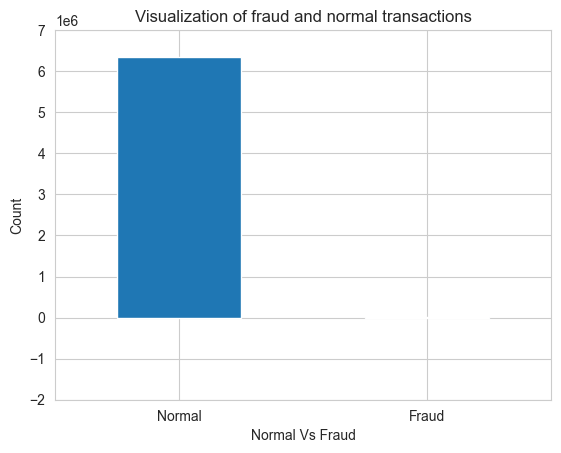

<Figure size 10000x10000 with 0 Axes>

In [18]:
# Visualize
labels = ["Normal", "Fraud"]
count_classes = df.value_counts(df['isFraud'], sort=True)
count_classes.plot(kind = "bar", rot = 0)
plt.title("Visualization of fraud and normal transactions")
plt.ylabel("Count")
plt.xlabel("Normal Vs Fraud")
plt.ylim([-2e6, 7e6])
plt.xticks(range(2), labels)
plt.figure(figsize=(100,100))
plt.show()

In [19]:
df['isFraud'].value_counts()

isFraud
0    6343476
1       7717
Name: count, dtype: int64

<Axes: xlabel='isFraud', ylabel='count'>

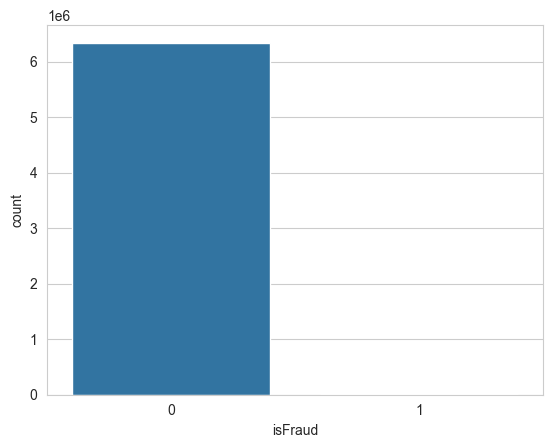

In [21]:
sb.countplot(df, x='isFraud')

As we can see from the figure above, there is an enormous difference between the transactions.

Only 0.13% (8,213) transactions in the dataset are fraudulent indicating hight class imbalance in the dataset. This is important becasue if we build a machine learning model on this highlt skewed data, the non-fraudulent transactions will influence the training of the model almost entirely, thus affecting the results.

#### Types of Transactions

In this section, let's explore the dataset by examining the type variable. We present what the different types of transactions are and which of these types can ve fraudulent.

The following plot shows the frequencies of the different transaction types:

In [22]:
print(df.type.value_counts(ascending=True))

type
DEBIT         41310
TRANSFER     531817
CASH_IN     1396865
PAYMENT     2147832
CASH_OUT    2233369
Name: count, dtype: int64


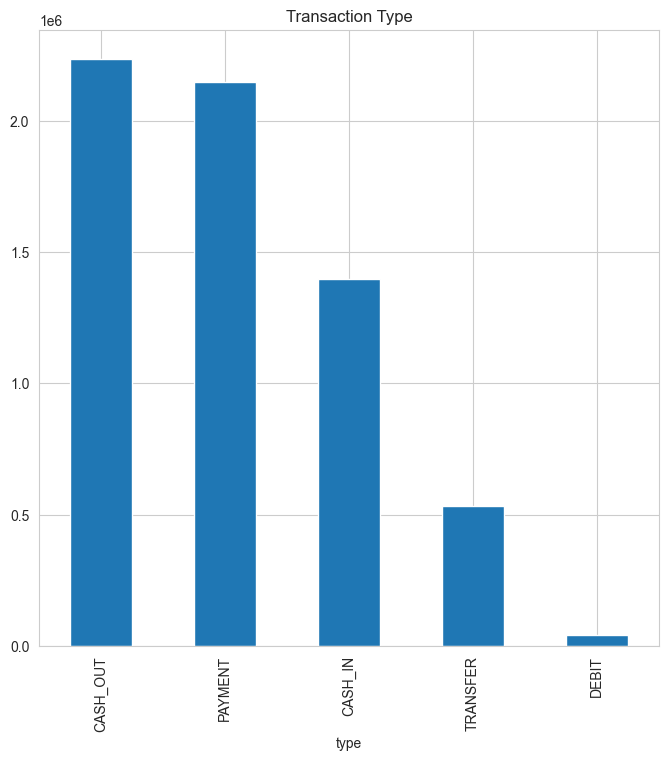

In [23]:
# Visualize the above data
f, ax = plt.subplots(1, 1, figsize=(8,8))
df.type.value_counts().plot(kind='bar', title="Transaction Type", ax=ax, figsize=(8,8))
plt.show()

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'PAYMENT'),
  Text(1, 0, 'TRANSFER'),
  Text(2, 0, 'CASH_OUT'),
  Text(3, 0, 'DEBIT'),
  Text(4, 0, 'CASH_IN')])

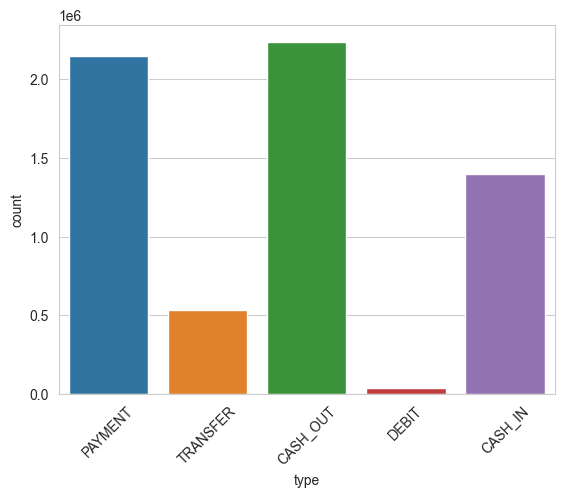

In [24]:
g= sb.countplot(x='type', data=df)
plt.xticks(rotation=45)

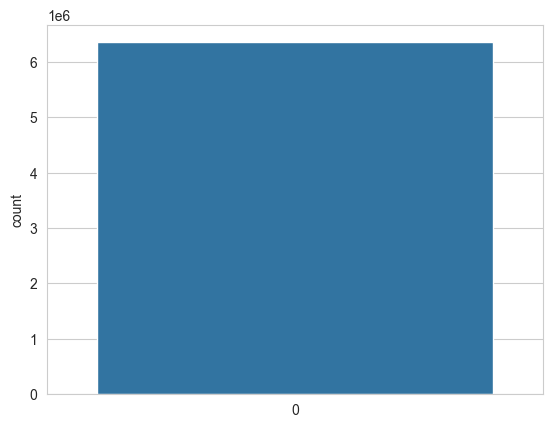

In [25]:
sb.countplot(data=df['isFraud'])
plt.show()

The most frequent transaction types are CASH-OUT and PAYMENT.

There are 1 flags which stand out to me and it's interesting to look into: isFraud  column. From the data Dictionary, isFraud is the indicator which indicates the actual fraud transactions.

Let's quickly check what kinds of transaction are being flagged and are fraud.

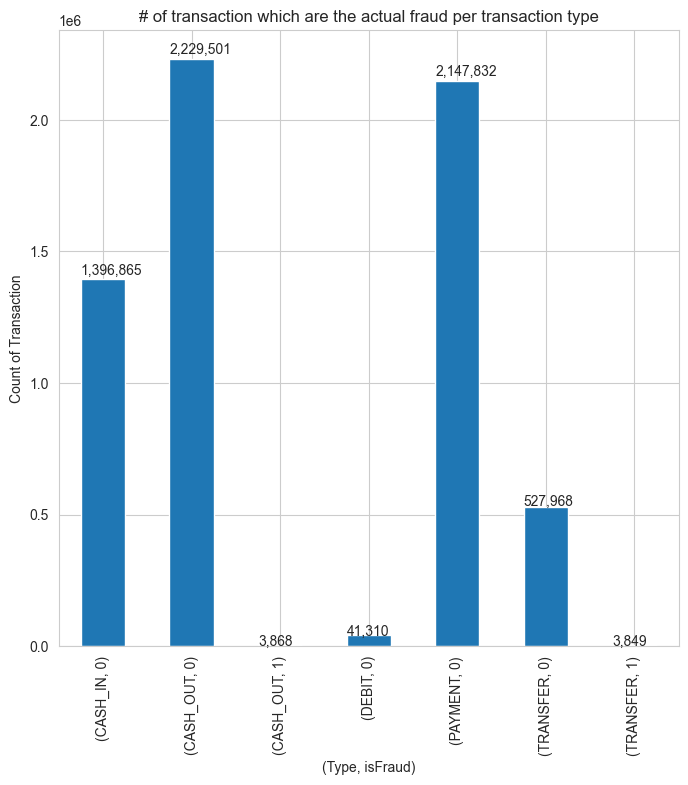

In [26]:
ax = df.groupby(['type', 'isFraud']).size().plot(kind='bar', figsize=(8,8))
ax.set_title("# of transaction which are the actual fraud per transaction type")
ax.set_xlabel("(Type, isFraud)")
ax.set_ylabel("Count of Transaction")
for p in ax.patches:
    ax.annotate(str(format(int(p.get_height()), ',d')), (p.get_x(), p.get_height()*1.01))

In [27]:
fraud_df = df[(df["isFraud"] == 1)]
fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7717 entries, 2 to 6351191
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            7717 non-null   int64  
 1   type            7717 non-null   object 
 2   amount          7717 non-null   float64
 3   nameOrig        7717 non-null   object 
 4   oldBalanceOrig  7717 non-null   float64
 5   newBalanceOrig  7717 non-null   float64
 6   nameDest        7717 non-null   object 
 7   oldBalanceDest  7717 non-null   float64
 8   newBalanceDest  7717 non-null   float64
 9   isFraud         7717 non-null   int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 663.2+ KB


In [28]:
non_fraud = len(fraud_df[fraud_df.isFraud == 0])
fraud = len(fraud_df[fraud_df.isFraud == 1])
print(non_fraud)
print(fraud)

0
7717


In [29]:
fraud_df.describe(include=['object'])

,type,nameOrig,nameDest
count,7717,7717,7717
unique,2,7717,7677
top,CASH_OUT,C1305486145,C385133759
freq,3868,1,2


In [30]:
fraud_df['type'].unique()

array(['TRANSFER', 'CASH_OUT'], dtype=object)

In [32]:
fraud_df['type'].value_counts()

type
CASH_OUT    3868
TRANSFER    3849
Name: count, dtype: int64

Only CASH-OUT and TRANSFER transactions can be fraudulent. So, it makes sense to retain only these two types of transactions in our dataset.

And from the above figure, the fraudulent transactions are splitted in an equal percentage.

Therefore, there is an almost equal likelihood that a fraudulent transaction can be CASH_OUT or TRANSFER.

Since only CASH-OUT and TRANSFER transactions can be fraudulent, let's reduce the size of the dataset by retaining only these transaction types and removing PAYMENT, CASH-IN and DEBIT.

In [33]:
new_df = df.loc[df['type'].isin(['CASH_OUT', 'TRANSFER']),:]
print('The new dataframe now has', len(new_df), 'transactions.')

The new dataframe now has 2765186 transactions.


In [34]:
new_df.describe(include=['object'])

,type,nameOrig,nameDest
count,2765186,2765186,2765186
unique,2,2763419,507780
top,CASH_OUT,C2098525306,C1286084959
freq,2233369,3,75


We managed to reduce the data from over 6 million transactions to ~2.8 million transactions.

### Data Sanity Checks
#### Negative or Zero Transaction Amount
First, let's check if the amount column is always positive. The following two code snippets break this into the number of transactions where the amount is negative and those where the amount is 0.

In [35]:
#Check that there are no negative amounts
print("Number of transactions where the transaction amount is negative: " + str(sum(new_df['amount'] < 0)))

#Check instances where transacted amount is 0
print("Number of transactions where the transaction amount is 0: " + str(sum(new_df['amount'] == 0)))

Number of transactions where the transaction amount is negative: 0
Number of transactions where the transaction amount is 0: 12


In [37]:
trans_0 = new_df[new_df['amount'] == 0]
len(trans_0)

12

In [38]:
len(trans_0[trans_0['isFraud']==1])

12

There are only a few cases in which transacted amount is 0. We observe by exploring the data of these transactios that they are all fradulent transactions. So, we can assume that if the transaction amount is 0, the transaction is fraudulent.

Let's remove these transactions from the data and include this condition while making the final predictions.

In [39]:
# Remove 0 amount values
new_df = new_df.loc[new_df['amount'] > 0,:]

In [40]:
len(new_df[new_df['amount']==0])

0

In [41]:
len(new_df[new_df['amount']<0])

0

In [42]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2765174 entries, 2 to 6351191
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldBalanceOrig  float64
 5   newBalanceOrig  float64
 6   nameDest        object 
 7   oldBalanceDest  float64
 8   newBalanceDest  float64
 9   isFraud         int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 232.1+ MB


#### Originator's balance and recipient's balance

In this section, let's check if there are any ambiguties in the originator's balance or recipient;s balance.

In [43]:
new_df_count = len(new_df)
orig_initial_balance = len(new_df[new_df.oldBalanceOrig == 0])
print("Percentage of transactions where originator's initial balance is 0: " + str(round((orig_initial_balance/new_df_count)*100, 2)))
dest_final_balance = len(new_df[new_df.newBalanceDest == 0])
print("Percentage of transactions where destination's final balance is 0: " + str(round(dest_final_balance/new_df_count*100, 2)))

Percentage of transactions where originator's initial balance is 0: 47.31
Percentage of transactions where destination's final balance is 0: 0.59


Therefore, in almost half of the transactions, the originator's initial balance was recorded as 0. However, in less than 1% of cases, the recipient's final balance was recorded as 0.

Ideally, the recipient's final balance should be equal to the reipient's initial balance plus the transaction amount. Similarly, the originator's final balance should be equal to originator's initial balance minus the transaction amount.

So, let's check these conditions to see whether the old balance and new balance varialbes are captured accurately for both originator and recipient.

In [44]:
new_df['dest_final_balance'] = new_df['oldBalanceDest'] + new_df['amount']
new_df.head()

/var/folders/vq/g110rjmd53bg177m6tkp18d00000gn/T/ipykernel_45114/374387572.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['dest_final_balance'] = new_df['oldBalanceDest'] + new_df['amount']


,step,type,amount,nameOrig,oldBalanceOrig,newBalanceOrig,nameDest,oldBalanceDest,newBalanceDest,isFraud,dest_final_balance
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,181.00
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,21363.00
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,234216.94
19,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,237735.30
24,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,317952.89


In [45]:
new_df['orig_final_balance'] = new_df['oldBalanceOrig'] - new_df['amount']
new_df.head()

/var/folders/vq/g110rjmd53bg177m6tkp18d00000gn/T/ipykernel_45114/4199300966.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['orig_final_balance'] = new_df['oldBalanceOrig'] - new_df['amount']


,step,type,amount,nameOrig,oldBalanceOrig,newBalanceOrig,nameDest,oldBalanceDest,newBalanceDest,isFraud,dest_final_balance,orig_final_balance
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,181.00,0.00
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,21363.00,0.00
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,234216.94,-213808.94
19,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,237735.30,-214605.30
24,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,317952.89,-300850.89


In [46]:
c1 = len(new_df[new_df.newBalanceDest != new_df.dest_final_balance])
print("Transation where destination balance are not accurately captured: "+ str(round(c1/new_df_count*100, 2)))

c2 = len(new_df[new_df.newBalanceOrig != new_df.orig_final_balance])
print("Transactions where originator balances are not accurately captured: " + str(round(c2/new_df_count*100, 2)))

Transation where destination balance are not accurately captured: 42.11
Transactions where originator balances are not accurately captured: 93.74


We can find that in most transactions, the originator's final balance is not accurately captured, and in almost half the cases, the recipient's final balance is not accurately captured.

It could be interesting to see if any of the above discrepancies identified vary between fraudulent transactions and non-fraudulent transactions. This will be done in subsequent sections.

#### Balances

In the previous section on Sanity Checks, we noticed that there are inaccuracies in how the balance varialbe is captured for both originator and recipient. We also observed that in almost half the cases, the originator's initial balance is recorded as 0.

In [47]:
fraud_trans = len(new_df[new_df.isFraud == 1])
c3 = len(new_df[(new_df.oldBalanceOrig == 0) & (new_df.isFraud == 1)])
print("% of fraudulent transactions where initial balance of orginator is 0: " + str(round(c3/fraud_trans*100, 2)))

gen_trans = len(new_df[new_df.isFraud == 0])
c4 = len(new_df[(new_df.oldBalanceOrig == 0) & (new_df.isFraud == 0)])
print("% of genuine transactions where initial balance of originator is 0: " + str(round(c4/gen_trans*100, 2)))

% of fraudulent transactions where initial balance of orginator is 0: 0.32
% of genuine transactions where initial balance of originator is 0: 47.44


In fraudulent transactions, originator’s initial balance is 0 only 0.3% of the time as compared to 47% in case of non-fraudulent transactions. This could be another potential differentiator between the two categories.

Let's check the inaccuracy in the balance variable and compare between fraud and nonfraud. The inaccuracy is defined as the difference between what the balance should be accounting for the transaction amount and what it is recorded as balance.

We calculate the balance inaccuracies for both the originator and destination as follows:

In [ ]:
new_df['origBalance_inacc'] = (new_df['oldBalanceOrig'] - new_df['amount']) - new_df['newBalanceOrig']
new_df['destBalance_inacc'] = (new_df['oldBalanceDest'] + new_df['amount']) - new_df['newBalanceDest']

In [ ]:
new_df.head()

Overall, we identified a few dimensions along which fraudulent transactions can be distinguished from non-fraudulent transactions. These are as follows:
- time step - fraudulent transactions have are equally likely to occur in all time steps, but genuine transactions peak in specific time steps
- balances - initial balance of originator is much more likely to be 0 in case of genuine transactions than fraud transactions
- inaccuracies in balance - inaccuracy in destination balance is likely to be negative in case of genuine transactions but positive in case of fraud transactions

## Predictive Modeling for Fraud Detection

In the previous sections, we identified dimensions that make fraudulent transactions detectable. Based on these results, let's build a supervised classification models.

### Modeling Dataset Creation

Let's choose the variables needed for the ML model, encode categorical varialbes as numberic and standardize the data.

The name of the originator and destination are not needed for classification. So, let's remove them.

In [ ]:
new_df = new_df.drop(['nameOrig', 'nameDest','dest_final_balance', 'orig_final_balance'], axis=1)
new_df.info()

Let's see the correlation of the selected datapoints from above.

In [ ]:
df_corr = new_df.drop(['type'], axis=1)

In [ ]:
corr_mat = df_corr.corr()

In [ ]:
corr_mat

In [ ]:
plt.figure(figsize=(15,15))
sb.heatmap(corr_mat, annot=True, cmap='Greens')
plt.show()

In [ ]:
sb.pairplot(df.iloc[0:50000], hue= 'isFraud')
plt.show()

### Outlier Identification

In [ ]:
# Also you can describe the data using histogram 
# which draws y-(number of instances) against x-(attribute in the dataset)

new_df.hist(bins=50, figsize=(20,25))
plt.show()

Identifying outliers in data is an important part of statistical analyses.  One
simple rule of thumb (due to John Tukey) for finding outliers is based on the
quartiles of the data: the first quartile $Q_1$ is the value $\geq 1/4$ of the
data, the second quartile $Q_2$ or the median is the value $\geq 1/2$ of the
data, and the third quartile $Q_3$ is the value $\geq 3/4$ of the data.  The
interquartile range, $IQR$, is $Q_3 - Q_1$.  

Tukey's rule says that the outliers are values more than $1.5$ times the interquartile range from the quartiles --- either below $Q_1 - 1.5 IQR$, or above $Q_3 + 1.5 IQR$.

In [48]:
attributes = new_df.columns

In [53]:
attributes

Index(['step', 'type', 'amount', 'nameOrig', 'oldBalanceOrig',
       'newBalanceOrig', 'nameDest', 'oldBalanceDest', 'newBalanceDest',
       'isFraud', 'dest_final_balance', 'orig_final_balance'],
      dtype='object')

In [54]:
numerical_attributes = [i for i in attributes if i not in ['step','type','nameOrig','nameDest','isFraud']]

In [55]:
numerical_attributes

['amount',
 'oldBalanceOrig',
 'newBalanceOrig',
 'oldBalanceDest',
 'newBalanceDest',
 'dest_final_balance',
 'orig_final_balance']

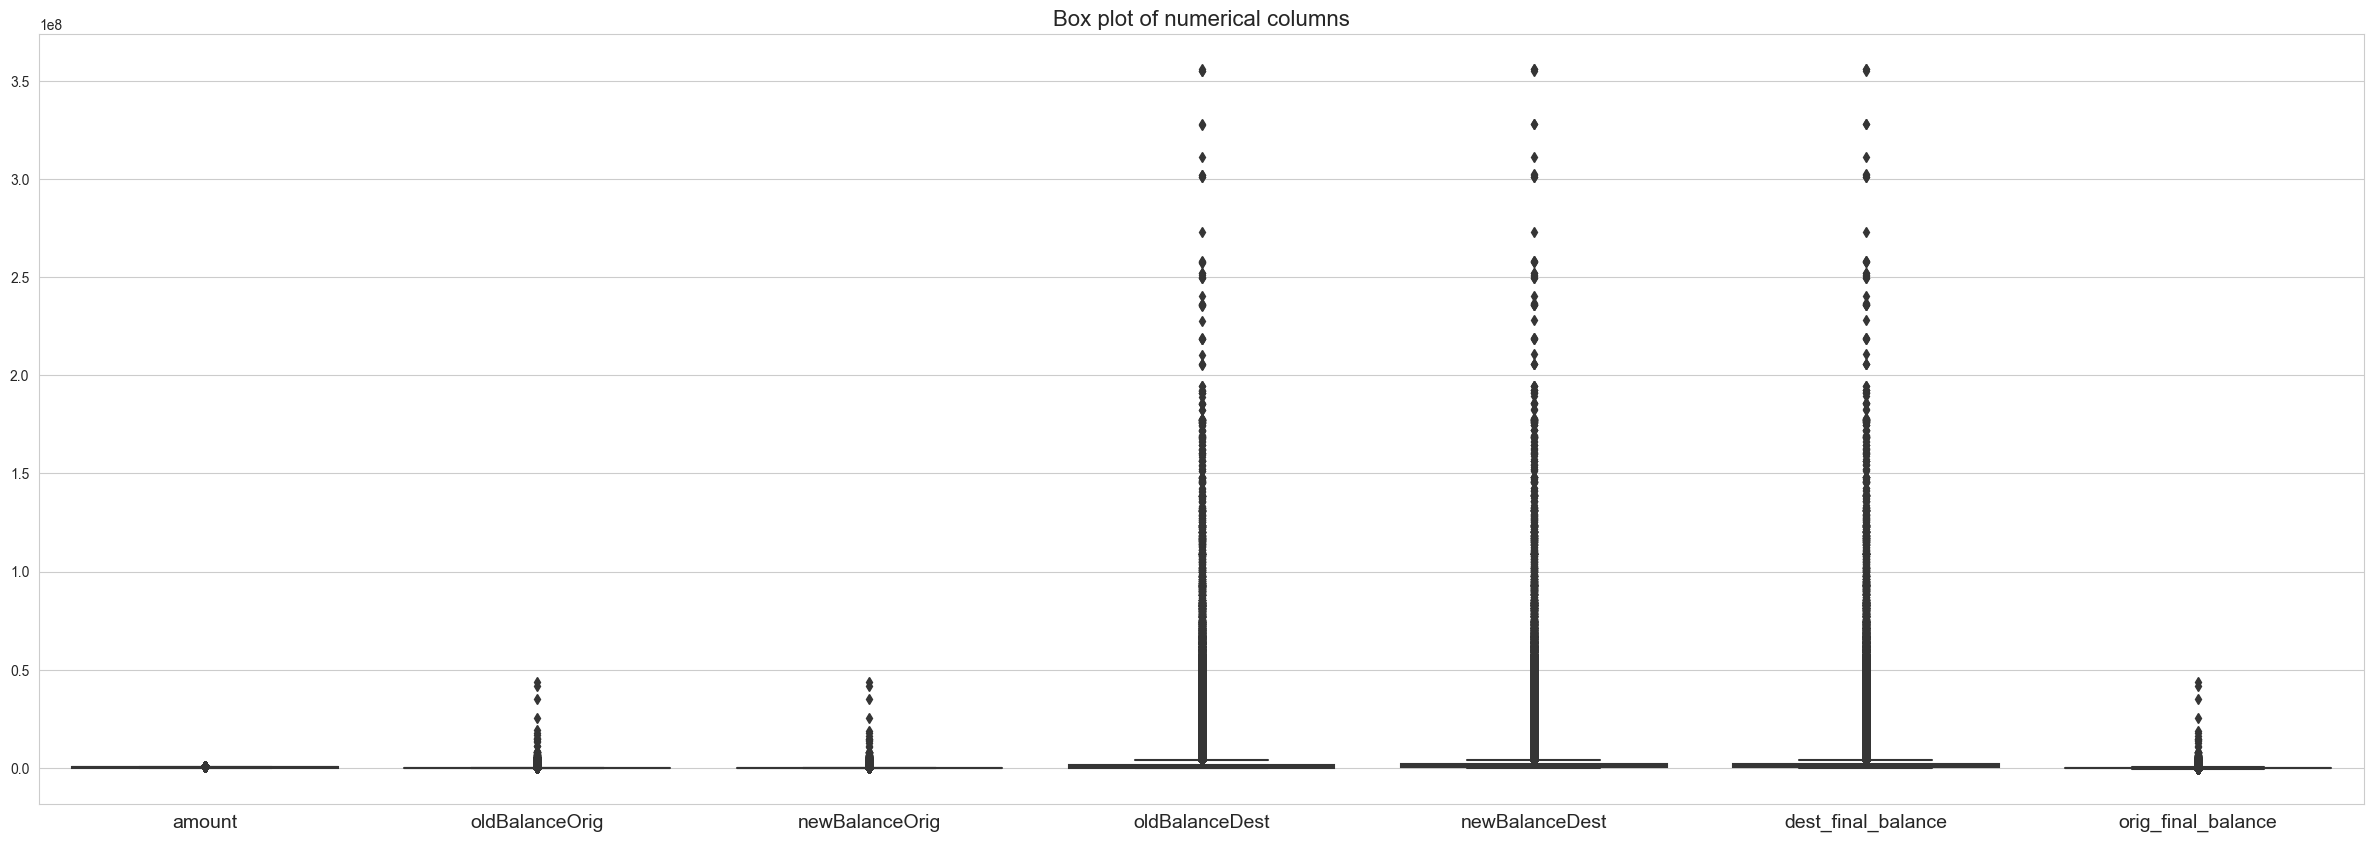

In [56]:
v0 = sb.color_palette(palette='viridis').as_hex()[0]
fig = plt.figure(figsize=(30,10))
sb.boxplot(data=new_df[numerical_attributes], color=v0,saturation=.5);
plt.xticks(fontsize= 14)
plt.title('Box plot of numerical columns', fontsize=16);

In [59]:
for i in numerical_attributes:
    iqr = new_df[i].quantile(0.75) - new_df[i].quantile(0.25)
    high_q = new_df[new_df[i]>new_df[i].quantile(0.75)+iqr*1.2]
    low_q = new_df[new_df[i]<new_df[i].quantile(0.25)-iqr*1.5]
    new_df = new_df.drop(high_q.index)
    new_df = new_df.drop(low_q.index)

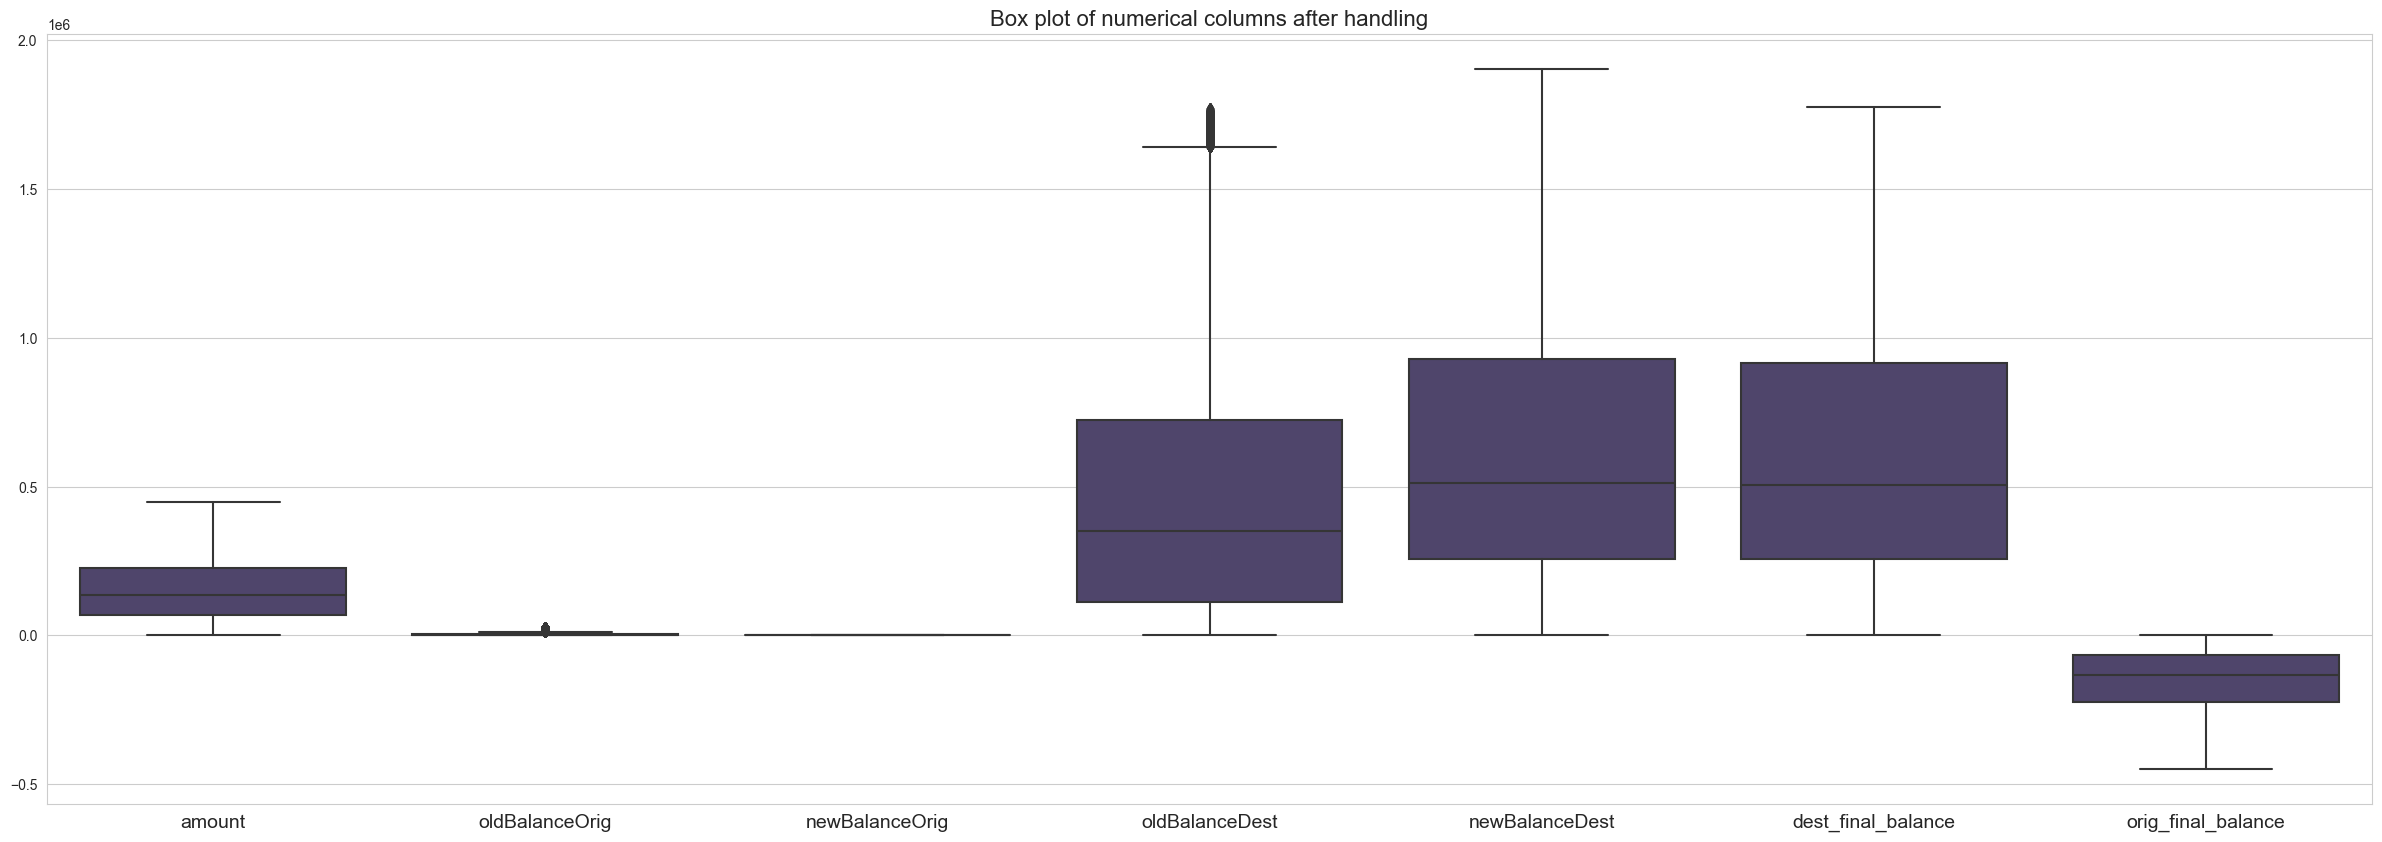

In [60]:
v0 = sb.color_palette(palette='viridis').as_hex()[0]
fig = plt.figure(figsize=(30,10))
sb.boxplot(data=new_df[numerical_attributes], color=v0,saturation=.5);
plt.xticks(fontsize= 14)
plt.title('Box plot of numerical columns after handling', fontsize=16);